In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

rfm = pd.read_csv('rfm_result.csv')
monthly = pd.read_csv('monthly_trend.csv')
category = pd.read_csv('category_revenue.csv')
region = pd.read_csv('region_revenue.csv')
top_products = pd.read_csv('top_products.csv')

rfm.head()

,Customer-036,Mandalay,81,272,586206500.0000000000,2,1,1.1
0,Customer-017,Yangon,2,269,592102000.0,3,1,1
1,Customer-086,Naypyitaw,0,282,607141000.0,3,1,1
2,Customer-061,Bago,131,292,647109500.0,1,2,1
3,Customer-022,Mandalay,31,276,647272500.0,3,1,1
4,Customer-050,Bago,0,272,648161000.0,4,1,1


### Insight: Monthly Sales Trend

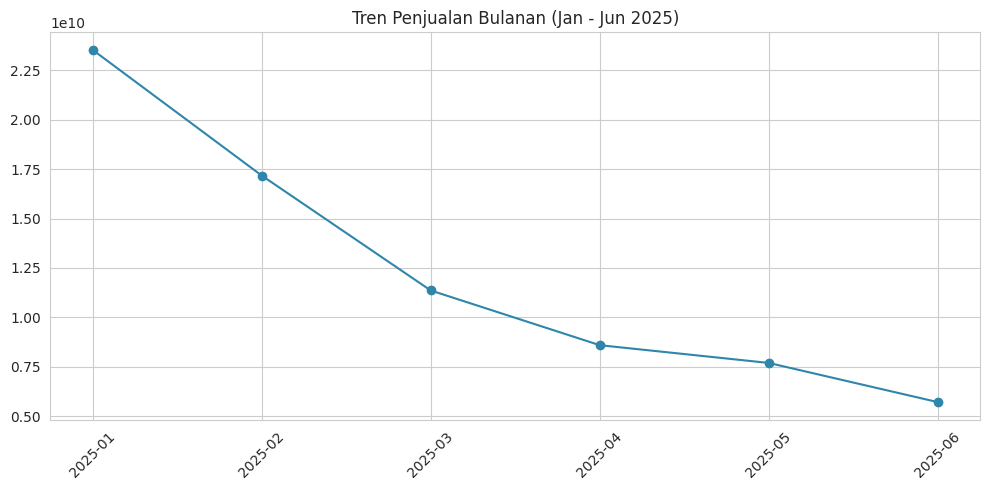

In [3]:
monthly = pd.read_csv('monthly_trend.csv', header=None,
                       names=['bulan', 'total_revenue', 'jumlah_transaksi'])

plt.figure(figsize=(10,5))
plt.plot(monthly['bulan'], monthly['total_revenue'], marker='o', color='#2E86AB')
plt.xticks(rotation=45)
plt.title('Tren Penjualan Bulanan (Jan - Jun 2025)')
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', dpi=150)
plt.show()



Revenue declined sharply and consistently from January to June 2025, dropping from approximately Rp23.5 billion to Rp5.7 billion — a decrease of roughly 76% over six months. Transaction volume followed the same downward pattern. This is the most striking finding in the dataset and suggests a structural issue (customer churn, reduced purchase frequency, or market saturation) rather than normal seasonal fluctuation, since the decline is monotonic across every month with no recovery.

### Insight: Revenue by Product Category



/tmp/ipykernel_1447/1510803092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category, y='ProductCategory', x='total_revenue', palette='viridis')


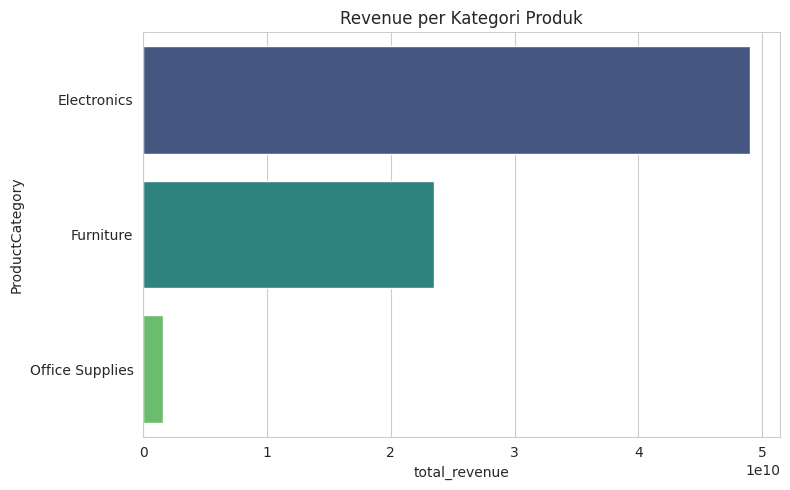

In [5]:
category = pd.read_csv('category_revenue.csv', header=None,
                        names=['ProductCategory', 'total_revenue', 'total_unit_terjual'])

plt.figure(figsize=(8,5))
sns.barplot(data=category, y='ProductCategory', x='total_revenue', palette='viridis')
plt.title('Revenue per Kategori Produk')
plt.tight_layout()
plt.savefig('chart_category.png', dpi=150)
plt.show()

Electronics dominates total revenue (~Rp49 billion), more than double Furniture (~Rp23.5 billion) and far ahead of Office Supplies (~Rp1.5 billion). This gap is partly explained by price per unit — Electronics items (monitors, headphones) carry much higher unit prices than Office Supplies (pens, paper) — but it also signals where the core revenue driver of the business lies, and where any decline would hurt most.

### Insight: Revenue by Region


/tmp/ipykernel_1447/1631574137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region, x='Region', y='total_revenue', palette='magma')


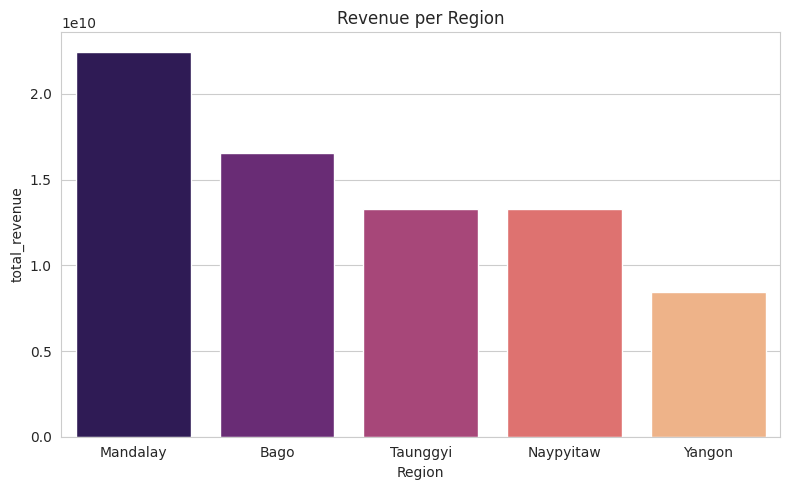

In [7]:
region = pd.read_csv('region_revenue.csv', header=None,
                      names=['Region', 'total_revenue', 'jumlah_customer', 'jumlah_transaksi'])

plt.figure(figsize=(8,5))
sns.barplot(data=region, x='Region', y='total_revenue', palette='magma')
plt.title('Revenue per Region')
plt.tight_layout()
plt.savefig('chart_region.png', dpi=150)
plt.show()

Mandalay generates the highest revenue (~Rp22.5 billion), followed by Bago (~Rp16.5 billion), while Taunggyi and Naypyitaw are nearly tied in the middle, and Yangon trails behind all other regions (~Rp8.5 billion) despite typically being a major commercial hub. This is worth investigating further — it may indicate fewer active customers in Yangon, or a smaller market presence there compared to the other regions.

### Insight: Top 10 Products by Revenue


/tmp/ipykernel_1447/3379156202.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y='ProductName', x='total_revenue', palette='crest')


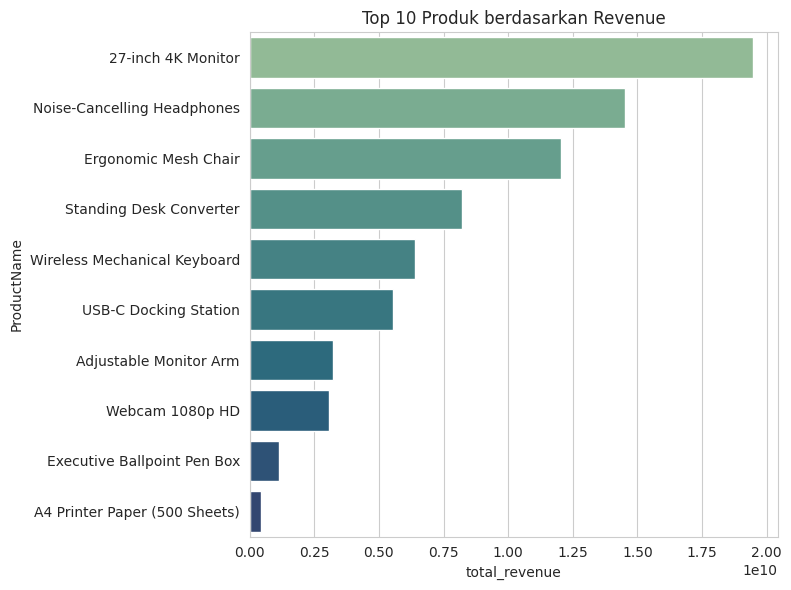

In [9]:
top_products = pd.read_csv('top_products.csv', header=None,
                            names=['ProductName', 'ProductCategory', 'total_qty_terjual', 'total_revenue'])

plt.figure(figsize=(8,6))
top10 = top_products.head(10)
sns.barplot(data=top10, y='ProductName', x='total_revenue', palette='crest')
plt.title('Top 10 Produk berdasarkan Revenue')
plt.tight_layout()
plt.savefig('chart_top_products.png', dpi=150)
plt.show()


The 27-inch 4K Monitor is the single best-performing product (~Rp19.5 billion), followed by Noise-Cancelling Headphones and the Ergonomic Mesh Chair. All three top products belong to Electronics or Furniture, reinforcing the category-level finding above. Office Supplies items (Executive Ballpoint Pen Box, A4 Printer Paper) occupy the bottom of the list, contributing comparatively little — these may be low-margin, high-frequency "filler" purchases rather than revenue drivers.

In [11]:
rfm = pd.read_csv('rfm_result.csv', header=None,
                   names=['CustomerID', 'Region', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score'])

rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

def segmentasi(row):
    if row['rfm_total'] >= 10:
        return 'Champion'
    elif row['rfm_total'] >= 7:
        return 'Loyal Customer'
    elif row['rfm_total'] >= 5:
        return 'At Risk'
    else:
        return 'Lost / Hibernating'

rfm['segment'] = rfm.apply(segmentasi, axis=1)
rfm['segment'].value_counts()

,count
segment,
Loyal Customer,43
At Risk,24
Champion,23
Lost / Hibernating,10


### Insight: Customer Segment Distribution



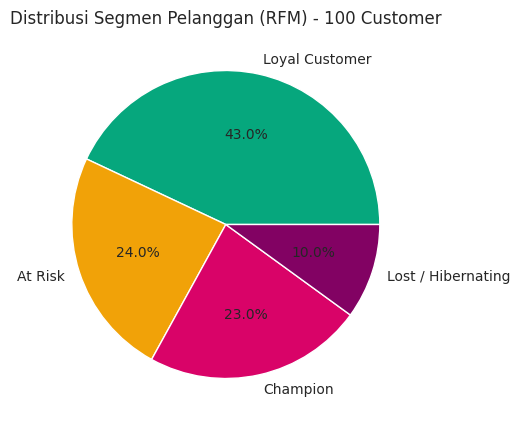

In [12]:
plt.figure(figsize=(7,5))
segment_counts = rfm['segment'].value_counts()
colors = ['#06A77D', '#F1A208', '#D90368', '#820263']
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Distribusi Segmen Pelanggan (RFM) - 100 Customer')
plt.savefig('chart_segment_pie.png', dpi=150)
plt.show()

Loyal Customers make up the largest share (43%), followed by At Risk (24%) and Champions (23%), with Lost/Hibernating customers being the smallest group (10%). While the high proportion of Loyal Customers looks positive on the surface, nearly a quarter of the customer base is already classified as At Risk — combined with the steep revenue decline seen in the monthly trend, this raises the question of whether today's "Loyal" customers are at risk of sliding into the "At Risk" category in the coming months if the downward trend continues.

### Insight: Revenue Contribution by Segment



/tmp/ipykernel_1447/4038380366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_per_segment.index, y=revenue_per_segment.values, palette='rocket')


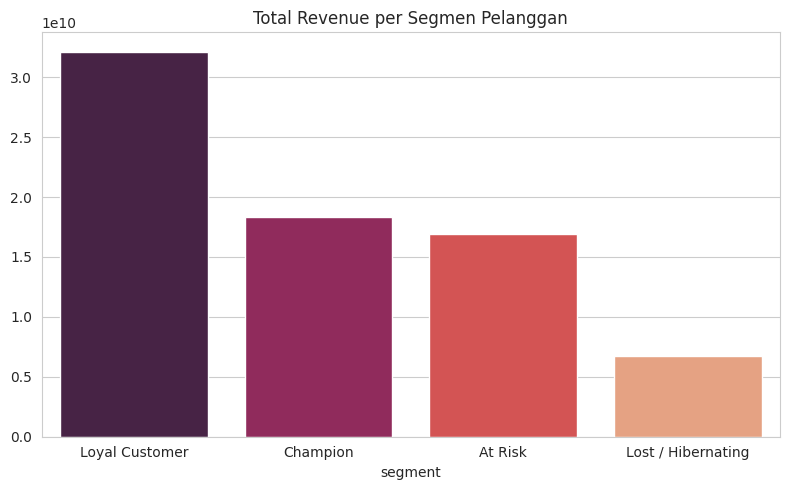

In [13]:
revenue_per_segment = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=revenue_per_segment.index, y=revenue_per_segment.values, palette='rocket')
plt.title('Total Revenue per Segmen Pelanggan')
plt.tight_layout()
plt.savefig('chart_revenue_segment.png', dpi=150)
plt.show()

Loyal Customers contribute the largest share of total revenue (~Rp32 billion), notably ahead of Champions (~Rp18.5 billion) and At Risk customers (~Rp17 billion), despite Champions and At Risk being similarly sized segments by customer count (23% vs 24%). This suggests Loyal Customers are not just the most numerous, but also the most valuable segment on average — making them the highest-priority group to protect from churn, especially given the overall revenue decline.

### Insight: Segment Distribution by Region



segment    At Risk  Champion  Lost / Hibernating  Loyal Customer
Region                                                          
Bago             6         6                   2               8
Mandalay         7         4                   3              16
Naypyitaw        7         4                   2               5
Taunggyi         1         8                   1               8
Yangon           3         1                   2               6


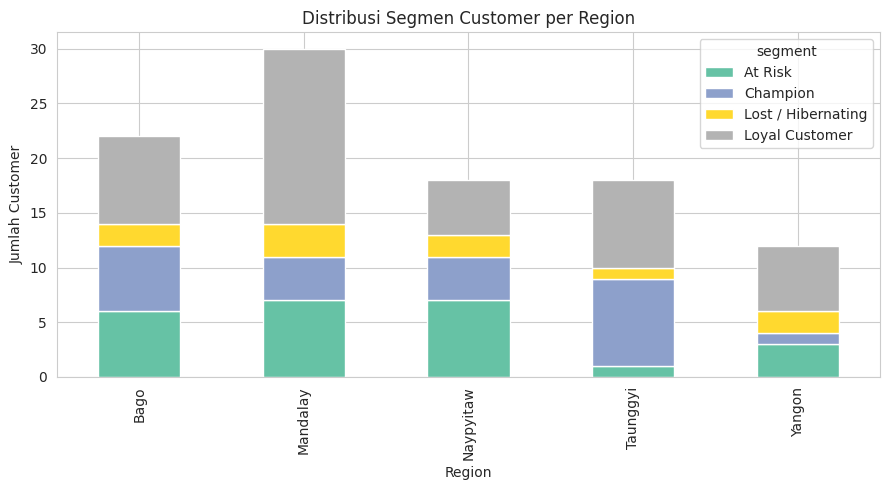

In [14]:
cross = pd.crosstab(rfm['Region'], rfm['segment'])
print(cross)

cross.plot(kind='bar', stacked=True, figsize=(9,5), colormap='Set2')
plt.title('Distribusi Segmen Customer per Region')
plt.ylabel('Jumlah Customer')
plt.tight_layout()
plt.savefig('chart_segment_per_region.png', dpi=150)
plt.show()

Customer segment composition varies meaningfully by region. Taunggyi stands out with a notably high concentration of Champions (9 out of 18 customers, roughly half) and very few At Risk or Lost/Hibernating customers — suggesting this region's customer base is unusually strong. In contrast, Yangon — despite having the lowest total revenue — shows a comparatively higher share of Lost/Hibernating customers relative to its total customer count, which may help explain why its revenue trails behind other regions.